<a href="https://colab.research.google.com/github/ruvxn/Traffic-Guidance-System/blob/main/notebooks/RNN_LSTM_GRU_TCN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
from sklearn.model_selection import train_test_split


X = np.load("/content/drive/MyDrive/Assignment2B/X_lstm_08.npy")
y = np.load("/content/drive/MyDrive/Assignment2B/y_lstm_08.npy")


X = X.reshape((X.shape[0], X.shape[1], 1))


In [3]:
from sklearn.preprocessing import MinMaxScaler
import joblib


In [7]:
from google.colab import files


files.download("/content/x_scaler_lstm.pkl")
files.download("/content/y_scaler_lstm.pkl")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)


In [8]:
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (402112, 8, 1), y shape: (402112,)


# RNN MODEL

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam

rnn_model = Sequential()


rnn_model.add(SimpleRNN(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
rnn_model.add(Dropout(0.2))


rnn_model.add(SimpleRNN(units=64, return_sequences=True))
rnn_model.add(Dropout(0.2))

rnn_model.add(SimpleRNN(units=32))
rnn_model.add(Dropout(0.2))


rnn_model.add(Dense(1))

rnn_model.compile(optimizer=Adam(), loss='mse', metrics=['mae'])




In [10]:
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 33s 5ms/step - loss: 11404.6338 - mae: 73.6721 - val_loss: 3202.1860 - val_mae: 31.8020
Epoch 2/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - loss: 2748.4536 - mae: 31.7448 - val_loss: 1437.1807 - val_mae: 22.4372
Epoch 3/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - loss: 1683.6616 - mae: 27.4945 - val_loss: 1107.7228 - val_mae: 19.3006
Epoch 4/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - loss: 1517.4971 - mae: 26.8315 - val_loss: 1073.1498 - val_mae: 19.5586
Epoch 5/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - loss: 1443.1204 - mae: 26.2326 - val_loss: 1006.3711 - val_mae: 18.8538
Epoch 6/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 1387.7793 - mae: 25.4910 - val_loss: 1002.8849 - val_mae: 19.0293
Epoch 7/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 43s 5ms/step - loss: 1325.6064 - mae: 24.9008 - val_loss: 967.4942 - val_mae: 18.6305
Epoch 8/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - loss: 1305.0266 - mae: 24.4891 - val_los

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

lstm_model = Sequential()
lstm_model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
lstm_model.add(Dropout(0.2))
lstm_model.add(LSTM(units=64, return_sequences=True))
lstm_model.add(Dropout(0.2))
lstm_model.add(LSTM(units=32))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer=Adam(), loss='mse', metrics=['mae'])

lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)


Epoch 1/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 52s 10ms/step - loss: 11380.1816 - mae: 73.0343 - val_loss: 3106.6892 - val_mae: 30.5641
Epoch 2/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 46s 9ms/step - loss: 2506.4717 - mae: 27.8797 - val_loss: 1238.0751 - val_mae: 19.7831
Epoch 3/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 84s 10ms/step - loss: 1242.2380 - mae: 20.7550 - val_loss: 895.2218 - val_mae: 17.1547
Epoch 4/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 80s 9ms/step - loss: 1041.7206 - mae: 19.5291 - val_loss: 840.6689 - val_mae: 17.2510
Epoch 5/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 48s 9ms/step - loss: 963.9662 - mae: 18.9863 - val_loss: 798.1518 - val_mae: 16.6023
Epoch 6/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 81s 9ms/step - loss: 939.8287 - mae: 18.8258 - val_loss: 787.3311 - val_mae: 16.7892
Epoch 7/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 48s 9ms/step - loss: 936.4143 - mae: 18.7982 - val_loss: 780.5233 - val_mae: 16.3327
Epoch 8/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 48s 10ms/step - loss: 925.1266 - mae: 18.6617 - val_loss: 75

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

gru_model = Sequential()
gru_model.add(GRU(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
gru_model.add(Dropout(0.2))
gru_model.add(GRU(units=64, return_sequences=True))
gru_model.add(Dropout(0.2))
gru_model.add(GRU(units=32))
gru_model.add(Dropout(0.2))
gru_model.add(Dense(1))

gru_model.compile(optimizer=Adam(), loss='mse', metrics=['mae'])

gru_history = gru_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 49s 9ms/step - loss: 11520.5850 - mae: 73.6889 - val_loss: 3175.0452 - val_mae: 31.4433
Epoch 2/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 46s 9ms/step - loss: 2587.4812 - mae: 28.6520 - val_loss: 1254.4801 - val_mae: 19.5918
Epoch 3/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 46s 9ms/step - loss: 1306.2411 - mae: 21.3761 - val_loss: 916.9540 - val_mae: 17.4011
Epoch 4/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 82s 9ms/step - loss: 1071.9541 - mae: 19.9761 - val_loss: 833.9622 - val_mae: 16.8121
Epoch 5/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 82s 9ms/step - loss: 998.2125 - mae: 19.4416 - val_loss: 804.9644 - val_mae: 16.3466
Epoch 6/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 81s 9ms/step - loss: 975.7603 - mae: 19.2843 - val_loss: 808.7485 - val_mae: 16.4551
Epoch 7/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 81s 9ms/step - loss: 957.7147 - mae: 19.1327 - val_loss: 831.0585 - val_mae: 17.0027
Epoch 8/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 82s 9ms/step - loss: 957.7487 - mae: 19.1452 - val_loss: 771.2

In [13]:
!pip install keras-tcn --quiet


In [14]:
from tcn import TCN

In [15]:
tcn_model = Sequential()
tcn_model.add(TCN(input_shape=(X_train.shape[1], X_train.shape[2]), nb_filters=64, kernel_size=3))
tcn_model.add(Dropout(0.2))
tcn_model.add(Dense(1))

tcn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

tcn_history = tcn_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)


/usr/local/lib/python3.11/dist-packages/tcn/tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


Epoch 1/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 53s 8ms/step - loss: 2417.7546 - mae: 25.5011 - val_loss: 960.1065 - val_mae: 18.9666
Epoch 2/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 28s 6ms/step - loss: 952.7390 - mae: 19.1770 - val_loss: 854.4877 - val_mae: 17.6495
Epoch 3/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - loss: 894.5547 - mae: 18.4204 - val_loss: 755.7069 - val_mae: 16.2863
Epoch 4/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - loss: 870.9988 - mae: 18.0491 - val_loss: 820.0961 - val_mae: 17.3790
Epoch 5/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - loss: 856.2648 - mae: 17.7879 - val_loss: 736.5784 - val_mae: 16.0122
Epoch 6/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - loss: 831.1182 - mae: 17.5124 - val_loss: 734.6234 - val_mae: 15.9861
Epoch 7/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - loss: 825.4039 - mae: 17.3502 - val_loss: 743.2138 - val_mae: 15.9831
Epoch 8/10
5027/5027 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - loss: 812.4035 - mae: 17.2663 - val_loss: 712.6971 - 

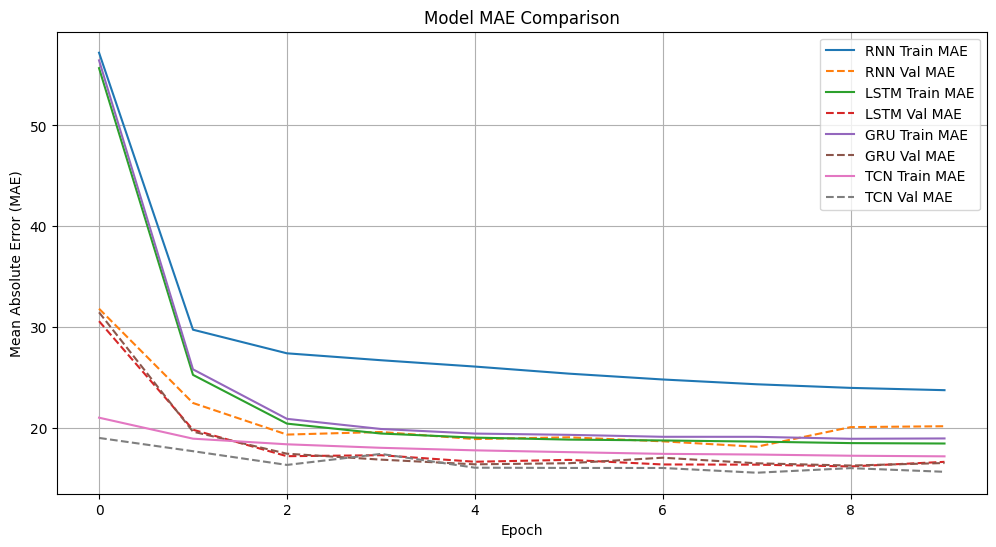

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))


plt.plot(rnn_history.history['mae'], label='RNN Train MAE', linestyle='-')
plt.plot(rnn_history.history['val_mae'], label='RNN Val MAE', linestyle='--')

plt.plot(lstm_history.history['mae'], label='LSTM Train MAE', linestyle='-')
plt.plot(lstm_history.history['val_mae'], label='LSTM Val MAE', linestyle='--')

plt.plot(gru_history.history['mae'], label='GRU Train MAE', linestyle='-')
plt.plot(gru_history.history['val_mae'], label='GRU Val MAE', linestyle='--')

plt.plot(tcn_history.history['mae'], label='TCN Train MAE', linestyle='-')
plt.plot(tcn_history.history['val_mae'], label='TCN Val MAE', linestyle='--')

plt.title('Model MAE Comparison')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend()
plt.grid(True)
plt.show()


In [17]:

y_pred_rnn = rnn_model.predict(X_test)
y_pred_lstm = lstm_model.predict(X_test)
y_pred_gru = gru_model.predict(X_test)
y_pred_tcn = tcn_model.predict(X_test)



2514/2514 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step


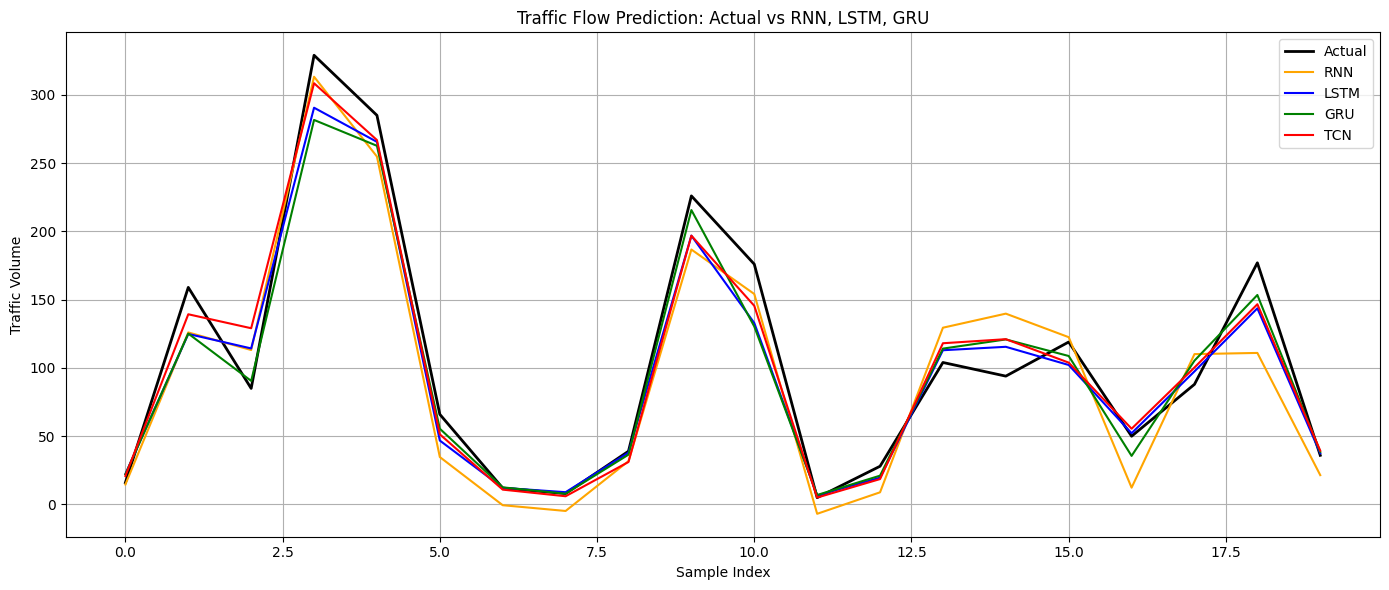

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Plot actual values
plt.plot(y_test[:20], label='Actual', color='black', linewidth=2)

# Plot predicted values from each model
plt.plot(y_pred_rnn[:20], label='RNN', color='orange', linestyle='-')
plt.plot(y_pred_lstm[:20], label='LSTM', color='blue', linestyle='-')
plt.plot(y_pred_gru[:20], label='GRU', color='green', linestyle='-')
plt.plot(y_pred_tcn[:20], label='TCN', color='red', linestyle='-')

plt.title('Traffic Flow Prediction: Actual vs RNN, LSTM, GRU')
plt.xlabel('Sample Index')
plt.ylabel('Traffic Volume')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


y_pred_rnn = rnn_model.predict(X_test).flatten()
y_pred_lstm = lstm_model.predict(X_test).flatten()
y_pred_gru = gru_model.predict(X_test).flatten()
y_pred_tcn = tcn_model.predict(X_test).flatten()

y_true = y_test.flatten()


def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f" {name} Performance:")
    print(f"   MAE  : {mae:.4f}")
    print(f"   MSE  : {mse:.4f}")
    print(f"   RMSE : {rmse:.4f}")
    print(f"   R²   : {r2:.4f}\n")









evaluate_model("RNN", y_true, y_pred_rnn)
evaluate_model("LSTM", y_true, y_pred_lstm)
evaluate_model("GRU", y_true, y_pred_gru)
evaluate_model("TCN", y_true, y_pred_tcn)





2514/2514 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
 RNN Performance:
   MAE  : 20.1285
   MSE  : 986.9079
   RMSE : 31.4151
   R²   : 0.8682

 LSTM Performance:
   MAE  : 16.5915
   MSE  : 766.6681
   RMSE : 27.6888
   R²   : 0.8976

 GRU Performance:
   MAE  : 16.4751
   MSE  : 771.1941
   RMSE : 27.7704
   R²   : 0.8970

 TCN Performance:
   MAE  : 15.6035
   MSE  : 710.2924
   RMSE : 26.6513
   R²   : 0.9052



In [24]:
rnn_model.save("/content/rnn_model.h5")
lstm_model.save("/content/lstm_model.h5")
gru_model.save("/content/gru_model.h5")
tcn_model.save("/content/tcn_model.h5")


In [25]:
from google.colab import files


files.download("/content/lstm_model.h5")
files.download("/content/gru_model.h5")
files.download("/content/rnn_model.h5")
files.download("/content/tcn_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>